# The YouTube Summarizer & Study Buddy

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook builds an **interactive Q&A system** for any YouTube video. Given a video URL, it fetches the transcript (subtitles), splits it into chunks, creates embeddings, and uses a local LLM (or Groq) to answer questions based *only* on the video content. This is a perfect study tool for lectures, tutorials, or any video content.

This project is part of Ibrahim's advanced RAG portfolio, demonstrating:
- Real‑time data ingestion from external APIs (YouTube transcripts)
- Chunking and vectorising long‑form video transcripts
- Question answering with source attribution
- Graceful fallback handling (if no Groq key, uses free Hugging Face model)

## Architecture
1. **YouTube Transcript Fetch** – `youtube-transcript-api` retrieves captions.
2. **Text Chunking** – Split transcript into overlapping chunks.
3. **Embeddings** – `sentence-transformers/all-MiniLM-L6-v2`.
4. **Vector Store** – FAISS in‑memory index.
5. **Retrieval** – Retrieve top‑k relevant chunks for a query.
6. **Generation** – Use Groq (or free local model) to answer based on retrieved context.
7. **Citations** – Show which part of the transcript was used.

## Sample Use Cases
- Summarise a long lecture
- Ask specific questions about a tutorial
- Extract key points from a conference talk

## Files Generated
- None (all in‑memory), but you can optionally save the FAISS index.

---

**© 2026 Ibrahim – YouTube RAG Study Assistant.**

### Install Dependencies

In [5]:
!pip install -q youtube-transcript-api langchain langchain-community langchain-groq langchain-classic faiss-cpu sentence-transformers langchain-huggingface langchain-text-splitters

### Imports

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api.formatters import TextFormatter
import warnings
warnings.filterwarnings('ignore')

# LangChain components – updated module paths
from langchain_text_splitters import RecursiveCharacterTextSplitter   # may be deprecated; fallback to langchain_text_splitters
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import RetrievalQA
from getpass import getpass
import os

print("Libraries imported.")

Libraries imported.


### Helper to Extract Video ID from YouTube URL

In [8]:
def extract_video_id(url):
    """Extract YouTube video ID from various URL formats."""
    patterns = [
        r'(?:youtube\.com\/watch\?v=)([\w-]+)',
        r'(?:youtu\.be\/)([\w-]+)',
        r'(?:youtube\.com\/embed\/)([\w-]+)',
        r'(?:youtube\.com\/v\/)([\w-]+)'
    ]
    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    raise ValueError(f"Could not extract video ID from URL: {url}")

### Fetch Transcript

In [12]:
!pip install -q --upgrade youtube-transcript-api

In [13]:
import re
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')

# ---------------- Library Import ----------------
# Install and import the required libraries
!pip install -q pytubefix faster-whisper
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api.formatters import TextFormatter
from pytubefix import YouTube
from faster_whisper import WhisperModel

# ---------------- Part A: The NEW & Simplified API ----------------
# This uses the instance-based method introduced in the latest library version[reference:1].
def get_transcript_simple(video_id):
    """Fetch transcript using the new instance-based API."""
    try:
        # Create an instance and list available transcripts
        ytt_api = YouTubeTranscriptApi()
        transcript_list = ytt_api.list(video_id)

        # Get the first available English transcript
        transcript = transcript_list.find_transcript(['en'])

        # Fetch the transcript data
        transcript_data = transcript.fetch()

        # Format to plain text
        formatter = TextFormatter()
        full_text = formatter.format_transcript(transcript_data)
        return full_text, transcript_data

    except Exception as e:
        return None, None


# ---------------- Part B: The BEST & Most Robust Method ----------------
# This version intelligently finds an English transcript, even if it's auto-generated.
def get_transcript_best(video_id):
    """Intelligently finds the best available English transcript."""
    try:
        ytt_api = YouTubeTranscriptApi()
        transcript_list = ytt_api.list(video_id)

        # 1. Try to find a manually created English transcript
        try:
            transcript = transcript_list.find_manually_created_transcript(['en'])
        except:
            # 2. If none exists, find an auto-generated English transcript
            try:
                transcript = transcript_list.find_generated_transcript(['en'])
            except:
                # 3. If no English transcript exists, get the first available one
                available_langs = [t.language for t in transcript_list]
                print(f"No English transcript found. Available languages: {available_langs}")
                if available_langs:
                    transcript = next(iter(transcript_list))
                else:
                    return None, None

        transcript_data = transcript.fetch()
        formatter = TextFormatter()
        full_text = formatter.format_transcript(transcript_data)
        return full_text, transcript_data

    except Exception as e:
        return None, None


# ---------------- Part C: THE RELIABLE FALLBACK ----------------
# If a video has no captions at all, use Whisper to transcribe its audio.
def transcribe_with_whisper(video_url):
    """Downloads video audio and transcribes it using Faster-Whisper (a high-quality, free, local model)."""
    print("No transcript found. Attempting to transcribe audio with Whisper (this will take a few minutes)...")

    # Download audio from the video URL using pytubefix
    yt = YouTube(video_url)
    stream = yt.streams.filter(only_audio=True).first()
    stream.download(filename="temp_audio.mp4")

    # Load the Whisper model (small is a good balance of speed and accuracy)
    model = WhisperModel("small", device="cpu", compute_type="int8")
    segments, info = model.transcribe("temp_audio.mp4", beam_size=5)

    # Combine all segments into a single text
    full_text = " ".join([segment.text for segment in segments])
    return full_text, None


# ---------------- Main Execution ----------------
def get_transcript_final(video_url):
    # Helper to extract video ID from URL (your existing function is fine)
    def extract_video_id(url):
        patterns = [
            r'(?:youtube\.com\/watch\?v=)([\w-]+)',
            r'(?:youtu\.be\/)([\w-]+)',
            r'(?:youtube\.com\/embed\/)([\w-]+)'
        ]
        for pattern in patterns:
            match = re.search(pattern, url)
            if match:
                return match.group(1)
        raise ValueError(f"Could not extract video ID from URL: {url}")

    video_id = extract_video_id(video_url)

    # First, try using the direct transcript method
    transcript_text, raw_transcript = get_transcript_best(video_id)
    if transcript_text:
        print(" Transcript fetched successfully.")
        return transcript_text, raw_transcript

    # If that fails, fall back to the Whisper transcription method
    sentence = "-----------------------------------------------------------------"
    print(f"{sentence}\n No transcript available.\n{sentence}")
    transcript_text, _ = transcribe_with_whisper(video_url)
    if transcript_text:
        print(" Audio transcribed successfully.")
        return transcript_text, None

    print(" Could not retrieve transcript or transcribe audio.")
    return None, None


# ---------------- Run the Code ----------------
default_url = "https://www.youtube.com/watch?v=6Yt6fuJ9Oss"  # A TED Talk that you know works.
print("Enter a YouTube video URL:")
video_url = input().strip()
if not video_url:
    video_url = default_url
    print(f"Using sample URL: {video_url}")

# Get the final transcript
transcript_text, raw_transcript = get_transcript_final(video_url)

if transcript_text:
    print(f"Transcript length: {len(transcript_text)} characters.")
    print(f"First 500 characters:\n{transcript_text[:500]}")
else:
    print("Failed to fetch or transcribe the video. Please try another URL.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.5 MB/s eta 0:00:00
Enter a YouTube video URL:
https://youtu.be/Q-ubFpiApi4
 Transcript fetched successfully.
Transcript length: 1107 characters.
First 500 characters:
Reed Hoffman has been right about every
single tech trend for the past 25 years.
And he says, "The way we use AI is about
to change forever." [music]
And this is what he posted. If you use
products like Whisper or ChatgBT Voice,
you know what I mean. Voice is simply
faster, [music] more natural, and more
flexible than typing. He said he's
voiceilled, and I can see why. Whisper
Flo

### Chunk Transcript

Split into 2 chunks.


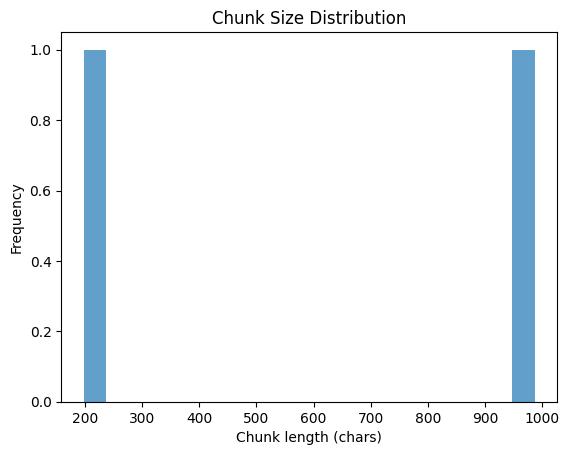

In [14]:
# Only proceed if we have transcript
if transcript_text:
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=100,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    chunks = text_splitter.split_text(transcript_text)
    print(f"Split into {len(chunks)} chunks.")
    # Show chunk lengths
    chunk_lengths = [len(c) for c in chunks]
    plt.hist(chunk_lengths, bins=20, alpha=0.7)
    plt.title('Chunk Size Distribution')
    plt.xlabel('Chunk length (chars)')
    plt.ylabel('Frequency')
    plt.show()
else:
    chunks = []

### Create Vector Store (FAISS)

In [15]:
if chunks:
    embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    print("Creating FAISS index from chunks...")
    vectorstore = FAISS.from_texts(chunks, embedding_model)
    print("FAISS index created.")
else:
    vectorstore = None

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Creating FAISS index from chunks...
FAISS index created.


### Set Up LLM (Groq with secure key prompt)

In [16]:
def setup_llm():
    key = getpass("Enter your Groq API key (or press Enter to use a free local model): ")
    if key:
        os.environ["GROQ_API_KEY"] = key
        llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)
        print("Using Groq LLM (fast inference).")
        return llm
    else:
        print("No API key. Using a free Hugging Face pipeline (slower).")
        from transformers import pipeline
        pipe = pipeline("text-generation", model="HuggingFaceH4/zephyr-7b-beta", device_map="auto")
        # We'll create a simple wrapper
        class LocalLLM:
            def invoke(self, prompt):
                result = pipe(prompt, max_new_tokens=256, do_sample=False)[0]['generated_text']
                return result
        return LocalLLM()

llm = setup_llm()

Enter your Groq API key (or press Enter to use a free local model): ··········
Using Groq LLM (fast inference).


### Build QA Chain

In [17]:
if vectorstore and llm:
    retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

    prompt_template = """
    You are a helpful study assistant. Answer the question based ONLY on the provided transcript context.
    If the answer is not in the context, say "I cannot find that information in the video transcript."

    Context:
    {context}

    Question: {question}

    Provide a clear, concise answer. Also mention which part of the transcript you used.
    Answer:
    """
    PROMPT = PromptTemplate(template=prompt_template, input_variables=["context", "question"])

    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=retriever,
        chain_type_kwargs={"prompt": PROMPT},
        return_source_documents=True
    )
    print("QA chain ready. You can now ask questions about the video.")
else:
    print("Cannot build QA chain: missing transcript or LLM.")
    qa_chain = None

QA chain ready. You can now ask questions about the video.


### Ask Questions (Interactive Loop)

In [19]:
def ask_question(qa_chain, question):
    result = qa_chain.invoke({"query": question})
    answer = result["result"]
    source_docs = result["source_documents"]
    print(f"\n Question: {question}")
    print(f" Answer: {answer}")
    print(f" Sources: {len(source_docs)} chunks retrieved.")
    return answer

if qa_chain:
    print("\n" + "="*50)
    print("YouTube Study Buddy Ready. Ask anything about the video.")
    print("Type 'exit' to quit.")
    print("="*50)
    while True:
        user_q = input("\n Your question: ").strip()
        if user_q.lower() in ["exit", "quit"]:
            print("Goodbye!")
            break
        if not user_q:
            continue
        ask_question(qa_chain, user_q)
else:
    print("QA chain not available. Please re-run cells after fixing transcript/LLM.")


YouTube Study Buddy Ready. Ask anything about the video.
Type 'exit' to quit.

 Your question: Who is Reed HOffman?

 Question: Who is Reed HOffman?
 Answer: Reed Hoffman is a tech trend expert who has been right about every single tech trend for the past 25 years. 
(Used from the part of the transcript: "Reed Hoffman has been right about every single tech trend for the past 25 years.")
 Sources: 2 chunks retrieved.

 Your question: quit
Goodbye!


### Optional: Save FAISS Index to Drive

In [20]:
from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/youtube_rag_index'
if vectorstore:
    vectorstore.save_local(save_path)
    print(f"FAISS index saved to {save_path}")

Mounted at /content/drive
FAISS index saved to /content/drive/MyDrive/youtube_rag_index


### Final Summary

In [22]:
print("\n" + "="*50)
print("YouTube Summarizer & Study Buddy - COMPLETED")
print("Author: Ibrahim")
print("="*50)
if transcript_text:
    print(f" Processed video: {video_url}")
    print(f" Transcript length: {len(transcript_text)} characters")
    print(f" Chunks created: {len(chunks)}")
    print(f" LLM: {'Groq' if os.environ.get('GROQ_API_KEY') else 'Local Hugging Face'}")
    print("\nYou can now ask detailed questions about the video content.")
else:
    print(" Transcript could not be fetched. Ensure the video has English captions.")


YouTube Summarizer & Study Buddy - COMPLETED
Author: Ibrahim
 Processed video: https://youtu.be/Q-ubFpiApi4
 Transcript length: 1107 characters
 Chunks created: 2
 LLM: Groq

You can now ask detailed questions about the video content.
